# Besoin de client 3 : Modèle de Prédiction du Type d'Implantation d'une Borne VE


---


**Objectif :** Développer un modèle d'intelligence artificielle capable de prédire le type d’implantation d’une borne


---


Il faut donc prédire la colonne `implantation_station` (composée de 5 classes : voirie, parking privé à usage public, parking public, station dédiée recharge rapide, parking privé réservé clientèle) à partir des caractéristiques techniques et géographiques d'une borne de recharge électrique.

**Pipeline :**
1. Chargement & Exploration des données (EDA)
2. Justification et sélection des variables
3. Prétraitement & encodage
4. Entraînement de plusieurs modèles
5. GridSearchCV — optimisation des hyperparamètres
6. Évaluation des métriques
7. Sauvegarde des modèles
8. Script de prédiction final

## 1. Installation & Imports

In [7]:
# Installation (si besoin sur Colab)
# !pip install scikit-learn pandas numpy matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — Prétraitement
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Scikit-learn — Modèles
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Scikit-learn — Évaluation
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print('✅ Imports OK')

✅ Imports OK


## 2. Chargement des Données

In [18]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/exportIA.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,nom_amenageur,siren_amenageur,contact_amenageur,nom_operateur,contact_operateur,telephone_operateur,nom_enseigne,id_station_itinerance,id_station_local,...,datagouv_resource_id,datagouv_organization_or_owner,created_at,long,lat,consolidated_code_postal,consolidated_commune,consolidated_is_lon_lat_correct,consolidated_is_code_insee_verified,consolidated_is_code_insee_modified
0,1,syndicat mixte d'electricite de la guadeloupe ...,200010759.0,ep-energie@symeg.net,g-mob,contact@gmob.fr,+590590325142,gmob,frgobpies2024111385490003,ies2024111385490003,...,df592154-7616-4c01-9d89-6521e0011467,g-mob,2025-10-06t16:44:59.145000+00:00,-61.572327,16.237882,97122.0,baie-mahault,True,True,False
1,2,syndicat mixte d'electricite de la guadeloupe ...,200010759.0,ep-energie@symeg.net,g-mob,contact@gmob.fr,+590590325142,gmob,frgobpies2024111385490003,ies2024111385490003,...,df592154-7616-4c01-9d89-6521e0011467,g-mob,2025-10-06t16:44:59.145000+00:00,-61.572327,16.237882,97122.0,baie-mahault,True,True,False
2,3,syndicat mixte d'electricite de la guadeloupe ...,200010759.0,ep-energie@symeg.net,g-mob,contact@gmob.fr,+590590325142,gmob,frgobpies2024111385490004,ies2024111385490004,...,df592154-7616-4c01-9d89-6521e0011467,g-mob,2025-10-06t16:44:59.145000+00:00,-61.636493,16.271696,97129.0,lamentin,True,True,False
3,4,syndicat mixte d'electricite de la guadeloupe ...,200010759.0,ep-energie@symeg.net,g-mob,contact@gmob.fr,+590590325142,gmob,frgobpies2024111385490004,ies2024111385490004,...,df592154-7616-4c01-9d89-6521e0011467,g-mob,2025-10-06t16:44:59.145000+00:00,-61.636493,16.271696,97129.0,lamentin,True,True,False
4,5,zetra distribution,895193019.0,contact@zetra.com,zetra distribution sas,contact@zetra.com,0170946050,zetra,frzetpmeura,NaN,...,fe8d0b39-4814-4bf1-9601-16e1dea20fa8,zetra-distribution,2025-06-17t15:36:54.011000+00:00,4.799711,48.967183,21190.0,tailly,False,True,False


## 3. Exploration & Justification des Variables

### 3.1 Analyse des valeurs manquantes

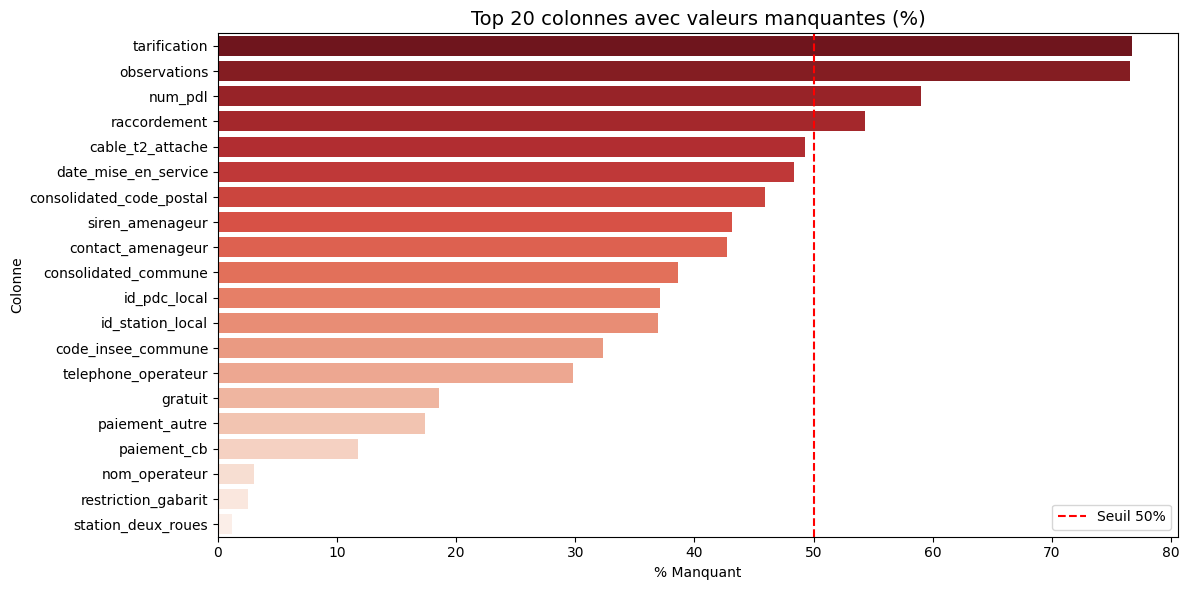


⚠️  Colonnes avec >50% de valeurs manquantes → exclues :
['tarification', 'observations', 'num_pdl', 'raccordement']


In [19]:
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['Colonne', '% Manquant']

plt.figure(figsize=(12, 6))
sns.barplot(data=missing_df.head(20), x='% Manquant', y='Colonne', palette='Reds_r')
plt.title('Top 20 colonnes avec valeurs manquantes (%)', fontsize=14)
plt.axvline(50, color='red', linestyle='--', label='Seuil 50%')
plt.legend()
plt.tight_layout()
plt.show()

print('\n⚠️  Colonnes avec >50% de valeurs manquantes → exclues :')
print(missing[missing > 50].index.tolist())

### 3.2 Justification et Sélection des Variables

| Variable | Type | Justification |
|---|---|---|
| `nbre_pdc` | Numérique | Nb de points de charge — corrélé à l'envergure de l'installation |
| `puissance_nominale` | Numérique | Puissance (kW) — distingue recharge rapide vs lente |
| `prise_type_ef` | Booléen | Type de connecteur — lié aux usages et implantations |
| `prise_type_2` | Booléen | Prise T2 — usage courant AC |
| `prise_type_combo_ccs` | Booléen | Connecteur DC rapide — station dédiée |
| `prise_type_chademo` | Booléen | CHAdeMO — recharge rapide |
| `prise_type_autre` | Booléen | Autres connecteurs |
| `paiement_acte` | Booléen | Paiement à l'acte — liés aux espaces publics |
| `paiement_cb` | Booléen | Paiement CB — infrastructure ouverte au public |
| `reservation` | Booléen | Réservation possible — usage privé/entreprise |
| `station_deux_roues` | Booléen | Adapté 2-roues — lié à la voirie |
| `condition_acces` | Catégoriel | Accès libre/réservé — discriminant fort |
| `accessibilite_pmr` | Catégoriel | Accessibilité PMR — infrastructure publique |
| `long` / `lat` | Numérique | Coordonnées GPS — contexte géographique |


In [20]:
# Variables sélectionnées
FEATURES_NUM = ['nbre_pdc', 'puissance_nominale', 'long', 'lat']

FEATURES_BOOL = [
    'prise_type_ef', 'prise_type_2', 'prise_type_combo_ccs',
    'prise_type_chademo', 'prise_type_autre',
    'paiement_acte', 'paiement_cb', 'reservation', 'station_deux_roues'
]

FEATURES_CAT = ['condition_acces', 'accessibilite_pmr']

TARGET = 'implantation_station'

ALL_FEATURES = FEATURES_NUM + FEATURES_BOOL + FEATURES_CAT

print(f'✅ {len(ALL_FEATURES)} variables sélectionnées sur {df.shape[1]} colonnes')
print(f'   - Numériques    : {FEATURES_NUM}')
print(f'   - Booléennes    : {FEATURES_BOOL}')
print(f'   - Catégorielles : {FEATURES_CAT}')

✅ 15 variables sélectionnées sur 53 colonnes
   - Numériques    : ['nbre_pdc', 'puissance_nominale', 'long', 'lat']
   - Booléennes    : ['prise_type_ef', 'prise_type_2', 'prise_type_combo_ccs', 'prise_type_chademo', 'prise_type_autre', 'paiement_acte', 'paiement_cb', 'reservation', 'station_deux_roues']
   - Catégorielles : ['condition_acces', 'accessibilite_pmr']


### 3.3 Visualisation de la distribution de la cible

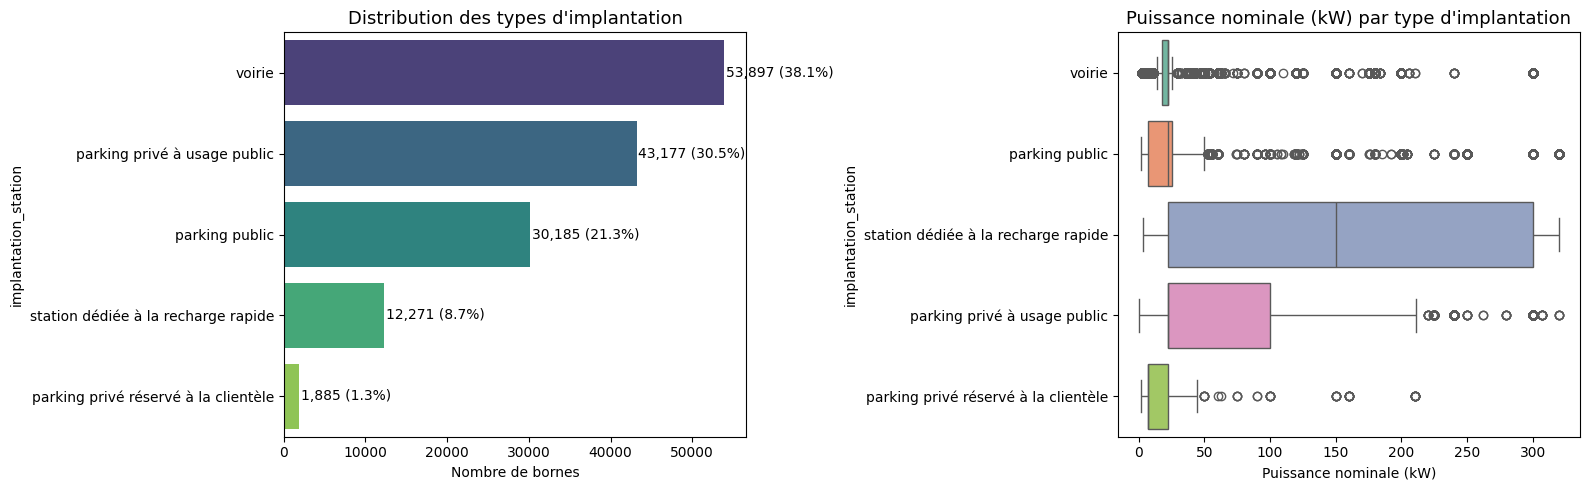

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution
counts = df[TARGET].value_counts()
sns.barplot(x=counts.values, y=counts.index, palette='viridis', ax=axes[0])
axes[0].set_title('Distribution des types d\'implantation', fontsize=13)
axes[0].set_xlabel('Nombre de bornes')
for i, v in enumerate(counts.values):
    axes[0].text(v + 200, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center')

# Puissance par implantation
df_plot = df[df['puissance_nominale'] < df['puissance_nominale'].quantile(0.99)]
sns.boxplot(data=df_plot, y=TARGET, x='puissance_nominale', palette='Set2', ax=axes[1])
axes[1].set_title('Puissance nominale (kW) par type d\'implantation', fontsize=13)
axes[1].set_xlabel('Puissance nominale (kW)')

plt.tight_layout()
plt.show()

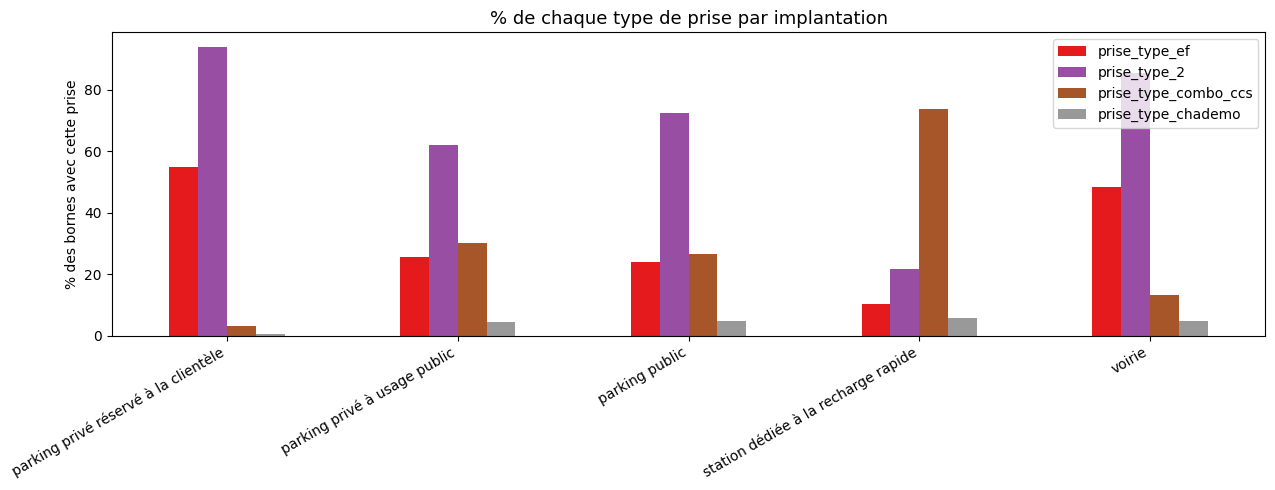

In [22]:
# Analyse des types de prises par implantation
prise_cols = ['prise_type_ef', 'prise_type_2', 'prise_type_combo_ccs', 'prise_type_chademo']
df_prise = df.copy()
for c in prise_cols:
    df_prise[c] = df_prise[c].map({'True': True, 'False': False, True: True, False: False})

prise_by_impl = df_prise.groupby(TARGET)[prise_cols].mean() * 100

prise_by_impl.plot(kind='bar', figsize=(13, 5), colormap='Set1')
plt.title('% de chaque type de prise par implantation', fontsize=13)
plt.ylabel('% des bornes avec cette prise')
plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 4. Prétraitement des Données

In [23]:
# Extraction du sous-ensemble utile
df_model = df[ALL_FEATURES + [TARGET]].copy()

# Nettoyage de la cible — suppression des lignes avec cible manquante
df_model = df_model.dropna(subset=[TARGET])
print(f'Lignes après suppression cible manquante : {len(df_model)}')

# Normalisation des colonnes booléennes (peuvent être en string 'True'/'False')
for col in FEATURES_BOOL:
    df_model[col] = df_model[col].map(
        {True: 1, False: 0, 'True': 1, 'False': 0, 'true': 1, 'false': 0}
    ).fillna(0).astype(int)

# Nettoyage des catégorielles (uniformisation encodage)
def normalize_cat(series):
    return series.fillna('inconnu').str.strip().str.lower()

for col in FEATURES_CAT:
    df_model[col] = normalize_cat(df_model[col])

# Encodage de la cible
le_target = LabelEncoder()
df_model['target_encoded'] = le_target.fit_transform(df_model[TARGET])
print(f'\n🎯 Classes encodées :')
for i, c in enumerate(le_target.classes_):
    print(f'  {i} → {c}')

# Sauvegarde du LabelEncoder de la cible
joblib.dump(le_target, 'label_encoder_target.joblib')
print('\n✅ label_encoder_target.joblib sauvegardé')

Lignes après suppression cible manquante : 141415

🎯 Classes encodées :
  0 → parking privé réservé à la clientèle
  1 → parking privé à usage public
  2 → parking public
  3 → station dédiée à la recharge rapide
  4 → voirie

✅ label_encoder_target.joblib sauvegardé


In [24]:
# Séparation X / y
X = df_model[ALL_FEATURES]
y = df_model['target_encoded']

# Split train / test (stratifié pour respecter la distribution des classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X_train.shape} | Test : {X_test.shape}')

# ─── Pipeline de prétraitement ───────────────────────────────────────────────
# Numériques : imputation par médiane + normalisation StandardScaler
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Booléens : imputation par 0 (valeur la plus fréquente par défaut)
bool_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0))
])

# Catégorielles : imputation 'inconnu' + encodage ordinal
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='inconnu')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Assemblage du ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num',  numeric_transformer,     FEATURES_NUM),
    ('bool', bool_transformer,        FEATURES_BOOL),
    ('cat',  categorical_transformer, FEATURES_CAT)
])

# Fit sur le train uniquement (important pour éviter le data leakage)
preprocessor.fit(X_train)

X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# ⚠️ Sauvegarde du préprocesseur — obligatoire pour le script final
joblib.dump(preprocessor, 'preprocessor.joblib')
print('✅ preprocessor.joblib sauvegardé')
print(f'Shape X_train_proc : {X_train_proc.shape}')

Train : (113132, 15) | Test : (28283, 15)
✅ preprocessor.joblib sauvegardé
Shape X_train_proc : (113132, 15)


## 5. Choix du Modèle & Entraînement

### Justification du choix algorithmique

Trois algorithmes sont comparés :

| Algorithme | Avantages | Inconvénients |
|---|---|---|
| **Random Forest** | Robuste, gère les non-linéarités, peu sensible aux outliers, feature importance | Moins interprétable qu'un arbre simple |
| **Gradient Boosting** | Très performant, bon biais-variance | Plus lent, sensible aux hyperparamètres |
| **Régression Logistique** | Rapide, interprétable | Suppose une relation linéaire |

> **Random Forest** est notre modèle principal : il excelle sur des données mixtes (numériques + catégorielles), résiste aux valeurs aberrantes, et fournit une **feature importance** utile pour la justification.

Random Forest             | Accuracy=0.9719 | F1=0.9719 | 23.0s
Gradient Boosting         | Accuracy=0.8072 | F1=0.8054 | 110.2s
Logistic Regression       | Accuracy=0.5947 | F1=0.5814 | 13.2s


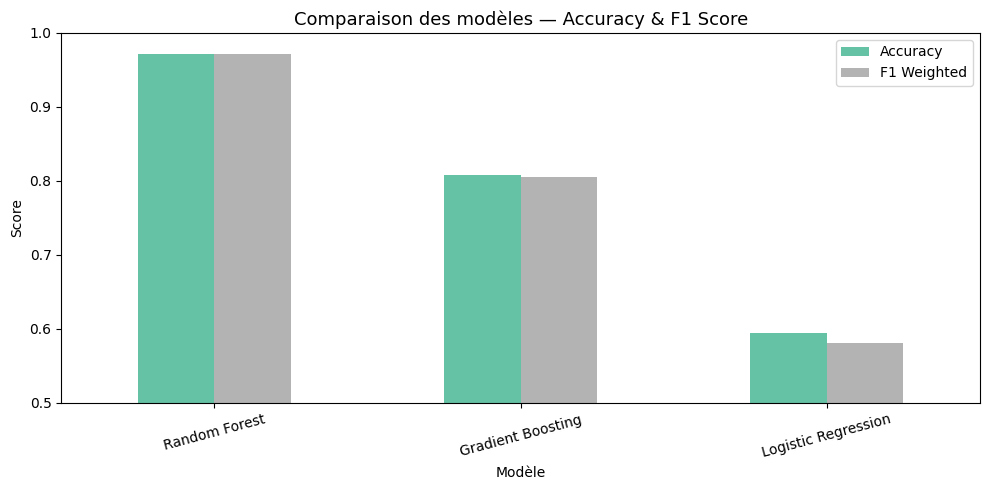

                     Accuracy  F1 Weighted  Temps (s)
Modèle                                               
Random Forest        0.971891     0.971878       23.0
Gradient Boosting    0.807234     0.805407      110.2
Logistic Regression  0.594739     0.581369       13.2


In [25]:
# Comparaison rapide des modèles de base
from time import time

models = {
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
}

results = []
for name, model in models.items():
    t0 = time()
    model.fit(X_train_proc, y_train)
    t1 = time()
    y_pred = model.predict(X_test_proc)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    results.append({'Modèle': name, 'Accuracy': acc, 'F1 Weighted': f1, 'Temps (s)': round(t1-t0, 1)})
    print(f'{name:25s} | Accuracy={acc:.4f} | F1={f1:.4f} | {t1-t0:.1f}s')

results_df = pd.DataFrame(results).set_index('Modèle')

# Graphe comparatif
results_df[['Accuracy', 'F1 Weighted']].plot(kind='bar', figsize=(10, 5), colormap='Set2', rot=15)
plt.title('Comparaison des modèles — Accuracy & F1 Score', fontsize=13)
plt.ylim(0.5, 1.0)
plt.ylabel('Score')
plt.tight_layout()
plt.show()
print(results_df)

## 6. Optimisation — GridSearchCV sur Random Forest

**Justification des métriques :**
- **Accuracy** : proportion de prédictions correctes — intuitive mais insuffisante si les classes sont déséquilibrées.
- **F1 Weighted** : moyenne des F1 par classe pondérée par le support — robuste au déséquilibre de classes. C'est notre **métrique principale**.
- **Matrice de confusion** : visualise les erreurs entre classes.

In [26]:
# ⚠️ GridSearchCV peut être long — réduire le dataset pour accélérer sur Colab
# Sous-échantillonnage stratifié pour la recherche d'hyperparamètres
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.8, random_state=42)
for train_idx, _ in sss.split(X_train_proc, y_train):
    X_gs = X_train_proc[train_idx]
    y_gs = y_train.iloc[train_idx]

print(f'Taille du sous-ensemble pour GridSearch : {X_gs.shape}')

# Grille d'hyperparamètres
param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
    'class_weight':      [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

print('🔍 Lancement du GridSearchCV...')
grid_search.fit(X_gs, y_gs)

print(f'\n✅ Meilleurs hyperparamètres :')
print(grid_search.best_params_)
print(f'\nMeilleur score F1 (CV) : {grid_search.best_score_:.4f}')

Taille du sous-ensemble pour GridSearch : (22626, 15)
🔍 Lancement du GridSearchCV...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

✅ Meilleurs hyperparamètres :
{'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Meilleur score F1 (CV) : 0.9156


## 7. Évaluation du Meilleur Modèle

In [27]:
best_model = grid_search.best_estimator_

# Ré-entraînement sur le train complet avec les meilleurs hyperparamètres
best_model.fit(X_train_proc, y_train)
y_pred_best = best_model.predict(X_test_proc)

acc_best = accuracy_score(y_test, y_pred_best)
f1_best  = f1_score(y_test, y_pred_best, average='weighted')

print(f'=== Résultats du meilleur modèle (Random Forest optimisé) ===')
print(f'Accuracy   : {acc_best:.4f}')
print(f'F1 Weighted: {f1_best:.4f}')
print()
print('=== Rapport de classification ===')
print(classification_report(y_test, y_pred_best, target_names=le_target.classes_))

=== Résultats du meilleur modèle (Random Forest optimisé) ===
Accuracy   : 0.9720
F1 Weighted: 0.9720

=== Rapport de classification ===
                                      precision    recall  f1-score   support

parking privé réservé à la clientèle       0.97      0.96      0.97       377
        parking privé à usage public       0.97      0.98      0.97      8636
                      parking public       0.96      0.95      0.95      6037
 station dédiée à la recharge rapide       0.99      0.99      0.99      2454
                              voirie       0.98      0.98      0.98     10779

                            accuracy                           0.97     28283
                           macro avg       0.97      0.97      0.97     28283
                        weighted avg       0.97      0.97      0.97     28283



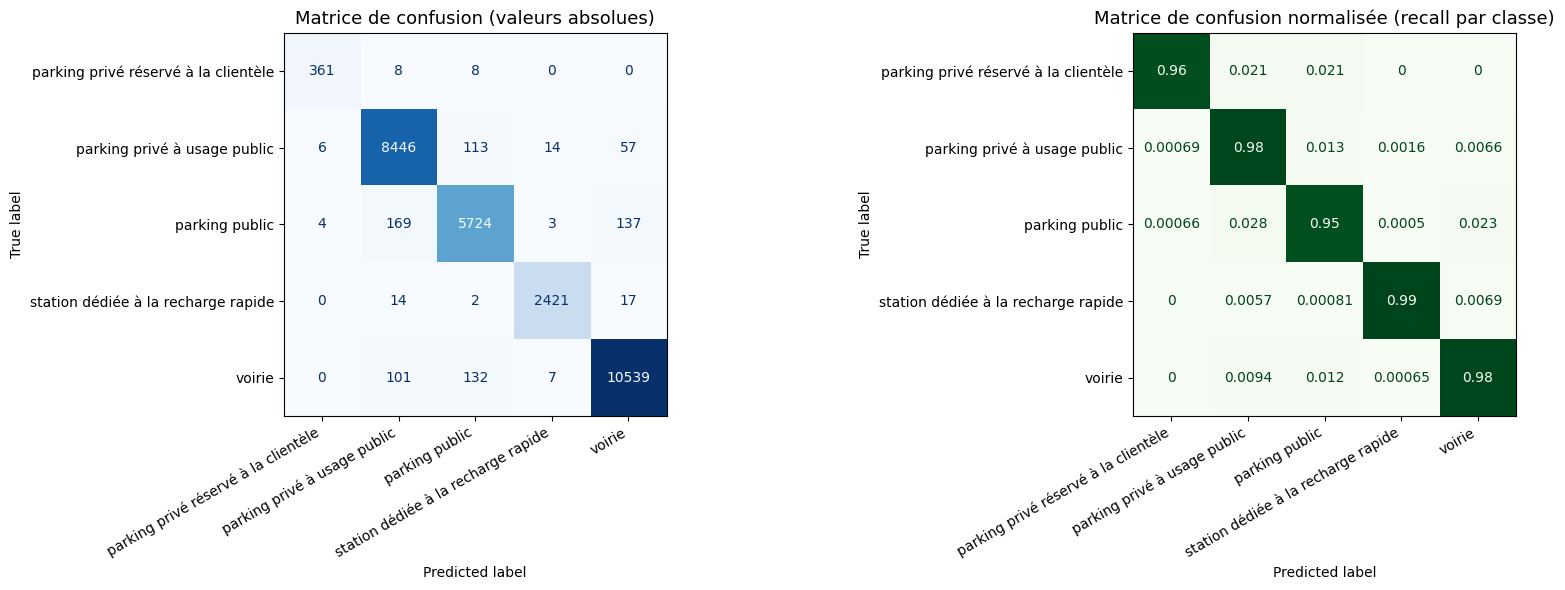

In [28]:
# Matrice de confusion
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Matrice absolue
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de confusion (valeurs absolues)', fontsize=13)
axes[0].set_xticklabels(le_target.classes_, rotation=30, ha='right')

# Matrice normalisée
cm_norm = confusion_matrix(y_test, y_pred_best, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=le_target.classes_)
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Matrice de confusion normalisée (recall par classe)', fontsize=13)
axes[1].set_xticklabels(le_target.classes_, rotation=30, ha='right')

plt.tight_layout()
plt.show()

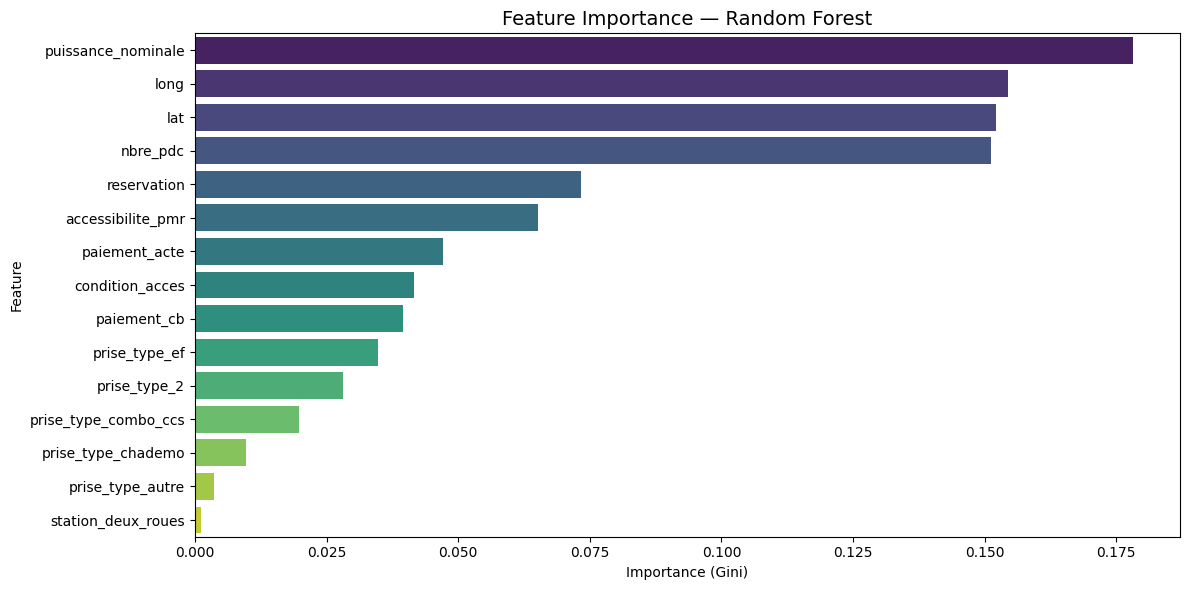


Tableau des importances :
             Feature  Importance
  puissance_nominale    0.178183
                long    0.154406
                 lat    0.152237
            nbre_pdc    0.151150
         reservation    0.073376
   accessibilite_pmr    0.065166
       paiement_acte    0.047074
     condition_acces    0.041704
         paiement_cb    0.039463
       prise_type_ef    0.034742
        prise_type_2    0.028194
prise_type_combo_ccs    0.019729
  prise_type_chademo    0.009686
    prise_type_autre    0.003702
  station_deux_roues    0.001188


In [29]:
# Feature Importance
feature_names = FEATURES_NUM + FEATURES_BOOL + FEATURES_CAT
importances = best_model.feature_importances_

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Importance (Gini)')
plt.tight_layout()
plt.show()

print('\nTableau des importances :')
print(fi_df.to_string(index=False))

=== Tableau des métriques par classe ===
                              Classe  Precision   Recall  F1 Score  Support
 station dédiée à la recharge rapide   0.990184 0.986553  0.988365     2454
                              voirie   0.980372 0.977734  0.979052    10779
        parking privé à usage public   0.966583 0.977999  0.972257     8636
parking privé réservé à la clientèle   0.973046 0.957560  0.965241      377
                      parking public   0.957351 0.948153  0.952730     6037


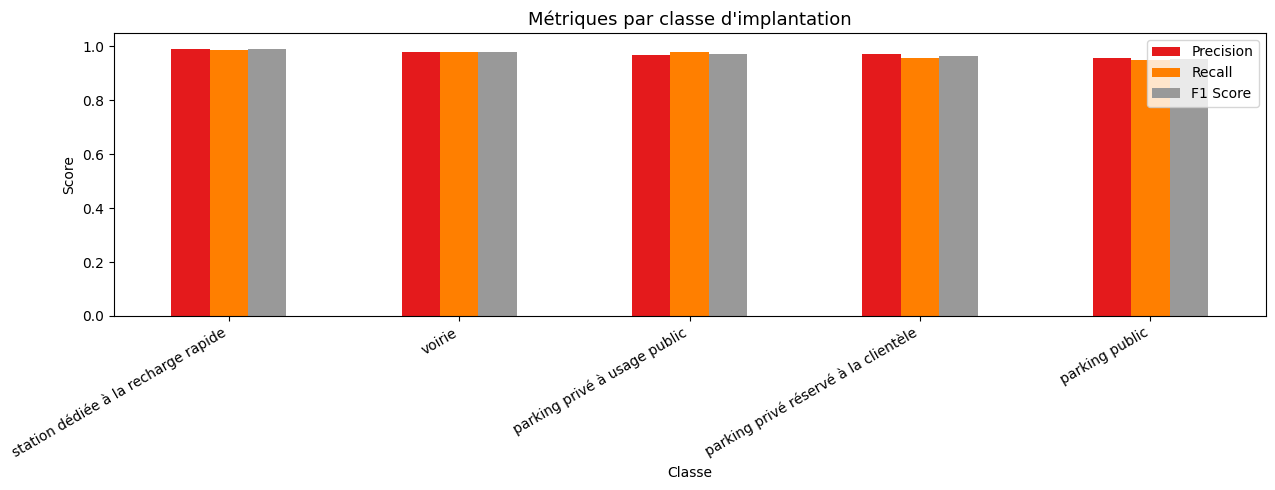

In [30]:
# Tableau récapitulatif des métriques par classe
from sklearn.metrics import precision_score, recall_score

metrics_table = pd.DataFrame({
    'Classe': le_target.classes_,
    'Precision': precision_score(y_test, y_pred_best, average=None),
    'Recall':    recall_score(y_test, y_pred_best, average=None),
    'F1 Score':  f1_score(y_test, y_pred_best, average=None),
    'Support':   cm.sum(axis=1)
})
metrics_table = metrics_table.sort_values('F1 Score', ascending=False)

print('=== Tableau des métriques par classe ===')
print(metrics_table.to_string(index=False))

# Graphe des métriques par classe
metrics_table_plot = metrics_table.set_index('Classe')[['Precision', 'Recall', 'F1 Score']]
metrics_table_plot.plot(kind='bar', figsize=(13, 5), colormap='Set1')
plt.title('Métriques par classe d\'implantation', fontsize=13)
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Sauvegarde des Modèles

> ⚠️ **Important :** Le script de prédiction charge ces fichiers — ne pas les supprimer.

In [31]:
# Sauvegarde du meilleur modèle
joblib.dump(best_model, 'best_model_rf.joblib')
# Sauvegarde du préprocesseur (déjà fait plus haut, mais on confirme)
joblib.dump(preprocessor, 'preprocessor.joblib')
# Sauvegarde du LabelEncoder
joblib.dump(le_target, 'label_encoder_target.joblib')
# Sauvegarde de la liste des features dans l'ordre
joblib.dump(ALL_FEATURES, 'feature_names.joblib')

print('✅ Fichiers sauvegardés :')
print('   • best_model_rf.joblib')
print('   • preprocessor.joblib')
print('   • label_encoder_target.joblib')
print('   • feature_names.joblib')

✅ Fichiers sauvegardés :
   • best_model_rf.joblib
   • preprocessor.joblib
   • label_encoder_target.joblib
   • feature_names.joblib


## 9. Script de Prédiction Final

Ce script charge les modèles pré-entraînés et effectue une prédiction sans réentraîner.

In [32]:
# ═══════════════════════════════════════════════════════════════════════════
#  SCRIPT DE PRÉDICTION — predict_implantation.py
#  Usage : predire l'implantation d'une borne à partir de ses caractéristiques
#  ⚠️ Ne réentraîne PAS le modèle — charge les fichiers .joblib pré-sauvegardés
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import joblib

def predict_implantation(borne_dict: dict) -> str:
    """
    Prédit le type d'implantation d'une borne VE.

    Parameters
    ----------
    borne_dict : dict
        Dictionnaire contenant les caractéristiques de la borne.
        Clés attendues :
            nbre_pdc (int), puissance_nominale (float),
            long (float), lat (float),
            prise_type_ef, prise_type_2, prise_type_combo_ccs,
            prise_type_chademo, prise_type_autre (0 ou 1),
            paiement_acte, paiement_cb, reservation,
            station_deux_roues (0 ou 1),
            condition_acces (str), accessibilite_pmr (str)

    Returns
    -------
    str : type d'implantation prédit
    """
    # Chargement des modèles sauvegardés
    model        = joblib.load('best_model_rf.joblib')
    preprocessor = joblib.load('preprocessor.joblib')
    le_target    = joblib.load('label_encoder_target.joblib')
    features     = joblib.load('feature_names.joblib')

    # Création du DataFrame avec les bonnes colonnes
    df_input = pd.DataFrame([borne_dict])[features]

    # Prétraitement
    X_proc = preprocessor.transform(df_input)

    # Prédiction
    y_pred_encoded = model.predict(X_proc)
    implantation   = le_target.inverse_transform(y_pred_encoded)[0]

    # Probabilités par classe
    probas = model.predict_proba(X_proc)[0]
    proba_dict = dict(zip(le_target.classes_, probas))

    return implantation, proba_dict


# ─── EXEMPLE D'UTILISATION ─────────────────────────────────────────────────
exemple_borne = {
    'nbre_pdc':            4,
    'puissance_nominale':  50.0,
    'long':                2.3522,
    'lat':                 48.8566,
    'prise_type_ef':       0,
    'prise_type_2':        1,
    'prise_type_combo_ccs':1,
    'prise_type_chademo':  1,
    'prise_type_autre':    0,
    'paiement_acte':       1,
    'paiement_cb':         1,
    'reservation':         0,
    'station_deux_roues':  0,
    'condition_acces':     'accès libre',
    'accessibilite_pmr':   'accessibilité inconnue'
}

implantation_pred, probas = predict_implantation(exemple_borne)

print(f'\n🔌 Prédiction du type d\'implantation :')
print(f'   → {implantation_pred}')
print(f'\n📊 Probabilités par classe :')
for classe, proba in sorted(probas.items(), key=lambda x: -x[1]):
    bar = '█' * int(proba * 30)
    print(f'   {classe:<45s} {proba:.3f}  {bar}')


🔌 Prédiction du type d'implantation :
   → parking privé à usage public

📊 Probabilités par classe :
   parking privé à usage public                  0.435  █████████████
   parking public                                0.340  ██████████
   voirie                                        0.115  ███
   station dédiée à la recharge rapide           0.090  ██
   parking privé réservé à la clientèle          0.020  


## 10. Synthèse

### Récapitulatif

| Étape | Décision | Justification |
|---|---|---|
| **Variables** | 15 features (num, bool, cat) | Pertinence métier + faible taux de valeurs manquantes |
| **Prétraitement** | Imputation médiane/constante + StandardScaler + OrdinalEncoder | Adapté aux types de données mixtes |
| **Algorithme** | Random Forest | Robustesse, feature importance, multiclasse natif |
| **Optimisation** | GridSearchCV 5-fold stratifié | Exploration exhaustive, respect de la distribution des classes |
| **Métrique principale** | F1 Weighted | Robuste au déséquilibre de classes (voirie >> parking privé clientèle) |
| **Fichiers sauvegardés** | 4 fichiers .joblib | Prédiction sans réentraînement |

### Fichiers produits
- `best_model_rf.joblib` — Modèle Random Forest optimisé
- `preprocessor.joblib` — Pipeline de prétraitement
- `label_encoder_target.joblib` — Encodeur de la cible
- `feature_names.joblib` — Ordre des features
